<a href="https://colab.research.google.com/github/Arhanabdullah/College-ML-Assignment/blob/main/Assignment-04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tower network graph created successfully!
Total number of nodes (towers): 7
Total number of edges (signal links): 9

Degree of each tower:
- T1: 2 connections
- T2: 3 connections
- T3: 4 connections
- T4: 2 connections
- T5: 2 connections
- T6: 3 connections
- T7: 2 connections
Tower(s) with the highest degree (4 connections): T3

Shortest path between T1 and T7: T1 -> T2 -> T7
Length of the shortest path: 2

Centrality Measures:
- T1:
  Degree Centrality: 0.333
  Betweenness Centrality: 0.000
  Closeness Centrality: 0.545
- T2:
  Degree Centrality: 0.500
  Betweenness Centrality: 0.122
  Closeness Centrality: 0.600
- T3:
  Degree Centrality: 0.667
  Betweenness Centrality: 0.422
  Closeness Centrality: 0.750
- T4:
  Degree Centrality: 0.333
  Betweenness Centrality: 0.089
  Closeness Centrality: 0.545
- T5:
  Degree Centrality: 0.333
  Betweenness Centrality: 0.056
  Closeness Centrality: 0.500
- T6:
  Degree Centrality: 0.500
  Betweenness Centrality: 0.256
  Closeness Centrality: 0.

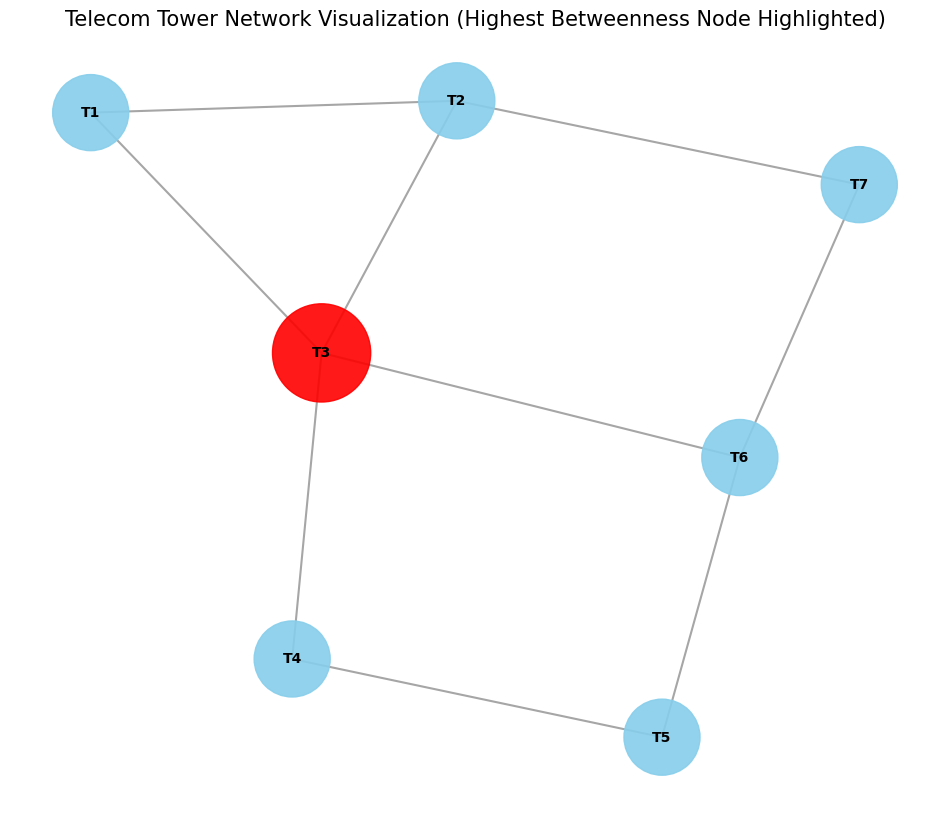


Observations about the overall structure of the tower network:
1. Tower T3 exhibits the highest Betweenness Centrality, making it a critical bridge or connector in the network. A failure of this tower would significantly disrupt communication flow between other parts of the network.
2. Towers with high Degree Centrality, such as T3, are important local hubs directly connected to many other towers. These towers are crucial for local connectivity and signal distribution.
3. Given the network is fully connected, signals can reach any tower from any other tower. However, the presence of towers with high Betweenness Centrality suggests that some paths are more dependent on specific intermediate towers than others.


In [9]:
import networkx as nx
import matplotlib.pyplot as plt

connections = [
    ("T1", "T2"),
    ("T1", "T3"),
    ("T2", "T3"),
    ("T3", "T4"),
    ("T4", "T5"),
    ("T5", "T6"),
    ("T3", "T6"),
    ("T6", "T7"),
    ("T2", "T7")
]

G_towers = nx.Graph()
G_towers.add_edges_from(connections)

print("Tower network graph created successfully!")

num_nodes = G_towers.number_of_nodes()
num_edges = G_towers.number_of_edges()

print(f"Total number of nodes (towers): {num_nodes}")
print(f"Total number of edges (signal links): {num_edges}")

print("\nDegree of each tower:")
degrees = dict(G_towers.degree())
for tower, degree in degrees.items():
    print(f"- {tower}: {degree} connections")

max_degree = 0
highest_degree_towers = []
for tower, degree in degrees.items():
    if degree > max_degree:
        max_degree = degree
        highest_degree_towers = [tower]
    elif degree == max_degree:
        highest_degree_towers.append(tower)

print(f"Tower(s) with the highest degree ({max_degree} connections): {', '.join(highest_degree_towers)}")

try:
    shortest_path_t1_t7 = nx.shortest_path(G_towers, source="T1", target="T7")
    shortest_path_length_t1_t7 = nx.shortest_path_length(G_towers, source="T1", target="T7")
    print(f"\nShortest path between T1 and T7: {' -> '.join(shortest_path_t1_t7)}")
    print(f"Length of the shortest path: {shortest_path_length_t1_t7}")
except nx.NetworkXNoPath:
    print("\nNo path exists between T1 and T7.")

degree_centrality = nx.degree_centrality(G_towers)
betweenness_centrality = nx.betweenness_centrality(G_towers)
closeness_centrality = nx.closeness_centrality(G_towers)

print("\nCentrality Measures:")
for node in G_towers.nodes():
    print(f"- {node}:\n  Degree Centrality: {degree_centrality[node]:.3f}\n  Betweenness Centrality: {betweenness_centrality[node]:.3f}\n  Closeness Centrality: {closeness_centrality[node]:.3f}")

is_connected = nx.is_connected(G_towers)
if is_connected:
    print("\nThe network is fully connected.")
else:
    num_components = nx.number_connected_components(G_towers)
    print(f"\nThe network is not fully connected. It has {num_components} connected component(s).")

highest_betweenness_node = max(betweenness_centrality, key=betweenness_centrality.get)

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_towers, k=0.7, iterations=50)

node_colors = ['skyblue' if node != highest_betweenness_node else 'red' for node in G_towers.nodes()]
node_sizes = [3000 if node != highest_betweenness_node else 5000 for node in G_towers.nodes()]

nx.draw_networkx_nodes(G_towers, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G_towers, pos, edge_color='gray', width=1.5, style='solid', alpha=0.7)
nx.draw_networkx_labels(G_towers, pos, font_size=10, font_weight='bold')

plt.title('Telecom Tower Network Visualization (Highest Betweenness Node Highlighted)', size=15)
plt.axis('off')
plt.show()

print(f"\nObservations about the overall structure of the tower network:")
print(f"1. Tower {highest_betweenness_node} exhibits the highest Betweenness Centrality, making it a critical bridge or connector in the network. A failure of this tower would significantly disrupt communication flow between other parts of the network.")
print(f"2. Towers with high Degree Centrality, such as {', '.join(highest_degree_towers)}, are important local hubs directly connected to many other towers. These towers are crucial for local connectivity and signal distribution.")
print(f"3. Given the network is fully connected, signals can reach any tower from any other tower. However, the presence of towers with high Betweenness Centrality suggests that some paths are more dependent on specific intermediate towers than others.")

Graph created successfully!


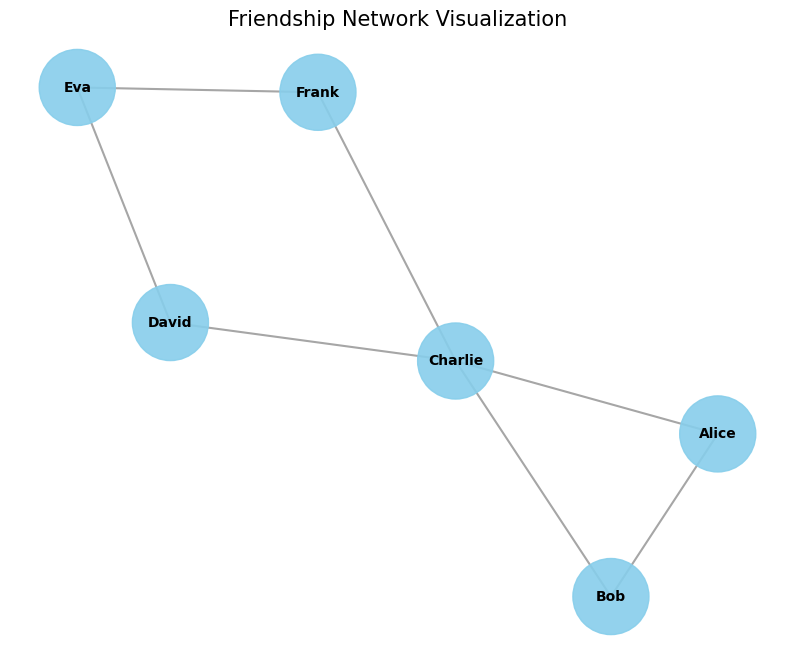

Total number of nodes (students): 6
Total number of edges (friendship connections): 7
Degree of each student:
- Alice: 2 friends
- Bob: 2 friends
- Charlie: 4 friends
- David: 2 friends
- Eva: 2 friends
- Frank: 2 friends
Student(s) with the highest number of friends (4 friends): Charlie
No, a direct friendship does not exist between Alice and Eva.
Shortest path between Alice and Frank: Alice -> Charlie -> Frank
Length of the shortest path: 2


In [10]:
import networkx as nx
import matplotlib.pyplot as plt

connections = [
    ("Alice", "Bob"),
    ("Alice", "Charlie"),
    ("Bob", "Charlie"),
    ("Charlie", "David"),
    ("David", "Eva"),
    ("Eva", "Frank"),
    ("Charlie", "Frank")
]

G = nx.Graph()

G.add_edges_from(connections)

print("Graph created successfully!")

plt.figure(figsize=(10, 8))

node_colors = ['skyblue' for _ in G.nodes()]

edge_colors = 'gray'
edge_widths = 1.5
edge_styles = 'solid'

pos = nx.spring_layout(G, k=0.7, iterations=50)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3000, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, style=edge_styles, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title('Friendship Network Visualization', size=15)
plt.axis('off')
plt.show()

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()

print(f"Total number of nodes (students): {num_nodes}")
print(f"Total number of edges (friendship connections): {num_edges}")

print("Degree of each student:")
for student, degree in G.degree():
    print(f"- {student}: {degree} friends")

degrees = dict(G.degree())
max_degree = 0
highest_degree_students = []

for student, degree in degrees.items():
    if degree > max_degree:
        max_degree = degree
        highest_degree_students = [student]
    elif degree == max_degree:
        highest_degree_students.append(student)

print(f"Student(s) with the highest number of friends ({max_degree} friends): {', '.join(highest_degree_students)}")

if G.has_edge("Alice", "Eva"):
    print("Yes, a direct friendship exists between Alice and Eva.")
else:
    print("No, a direct friendship does not exist between Alice and Eva.")

try:
    shortest_path = nx.shortest_path(G, source="Alice", target="Frank")
    shortest_path_length = nx.shortest_path_length(G, source="Alice", target="Frank")
    print(f"Shortest path between Alice and Frank: {' -> '.join(shortest_path)}")
    print(f"Length of the shortest path: {shortest_path_length}")
except nx.NetworkXNoPath:
    print("No path exists between Alice and Frank.")